In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [233]:
df = pd.read_csv(r"C:\Python\dr wael\updated_telecom_data.csv")
df.columns = df.columns.str.strip()
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,multiplelines,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,service,churn
0,7590-VHVEG,Female,0,Yes,No,1,No phone service,Month-to-month,Yes,Electronic check,29.85,29.85,1,No
1,5575-GNVDE,Male,0,No,No,34,No,One year,No,Mailed check,56.95,1889.5,1,No
2,3668-QPYBK,Male,0,No,No,2,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Yes
3,7795-CFOCW,Male,0,No,No,45,No phone service,One year,No,Bank transfer (automatic),42.30,1840.75,1,No
4,9237-HQITU,Female,0,No,No,2,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,Yes


In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   multiplelines     7043 non-null   object 
 7   contract          7043 non-null   object 
 8   paperlessbilling  7043 non-null   object 
 9   paymentmethod     7043 non-null   object 
 10  monthlycharges    7043 non-null   float64
 11  totalcharges      7043 non-null   object 
 12  service           7043 non-null   int64  
 13  churn             7043 non-null   object 
dtypes: float64(1), int64(3), object(10)
memory usage: 770.5+ KB


In [235]:
df.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
multiplelines       0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
service             0
churn               0
dtype: int64

In [236]:
df.describe()

,seniorcitizen,tenure,monthlycharges,service
count,7043.000000,7043.000000,7043.000000,7043.0
mean,0.162147,32.371149,64.761692,1.0
std,0.368612,24.559481,30.090047,0.0
min,0.000000,0.000000,18.250000,1.0
25%,0.000000,9.000000,35.500000,1.0
50%,0.000000,29.000000,70.350000,1.0
75%,0.000000,55.000000,89.850000,1.0
max,1.000000,72.000000,118.750000,1.0


In [237]:
df.duplicated().sum()

np.int64(0)

In [238]:
churn_counts = df["churn"].value_counts()
churn_counts

churn
No     5174
Yes    1869
Name: count, dtype: int64

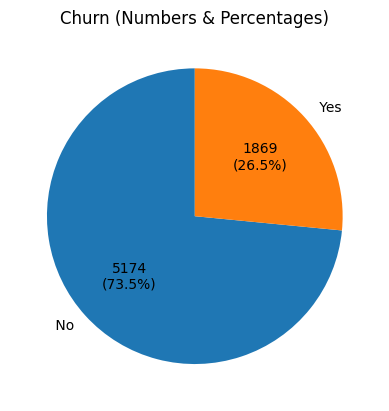

In [239]:
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    startangle=90,
    autopct=lambda p: f'{int(p/100 * sum(churn_counts))}\n({p:.1f}%)'
)
plt.title('Churn (Numbers & Percentages)')
plt.show()

In [240]:
df.drop("customerid",axis= 1 , inplace=True)

In [241]:
df.keys()

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'multiplelines', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'service', 'churn'],
      dtype='object')

In [242]:
ob_cols = df.select_dtypes(include=["object"])
ob_cols

,gender,partner,dependents,multiplelines,contract,paperlessbilling,paymentmethod,totalcharges,churn
0,Female,Yes,No,No phone service,Month-to-month,Yes,Electronic check,29.85,No
1,Male,No,No,No,One year,No,Mailed check,1889.5,No
2,Male,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,Male,No,No,No phone service,One year,No,Bank transfer (automatic),1840.75,No
4,Female,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes
...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No
7039,Female,Yes,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No
7040,Female,Yes,Yes,No phone service,Month-to-month,Yes,Electronic check,346.45,No
7041,Male,Yes,No,Yes,Month-to-month,Yes,Mailed check,306.6,Yes


In [243]:
df[df['totalcharges'].str.strip() == '']

,gender,seniorcitizen,partner,dependents,tenure,multiplelines,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,service,churn
488,Female,0,Yes,Yes,0,No phone service,Two year,Yes,Bank transfer (automatic),52.55,,1,No
753,Male,0,No,Yes,0,No,Two year,No,Mailed check,20.25,,1,No
936,Female,0,Yes,Yes,0,No,Two year,No,Mailed check,80.85,,1,No
1082,Male,0,Yes,Yes,0,Yes,Two year,No,Mailed check,25.75,,1,No
1340,Female,0,Yes,Yes,0,No phone service,Two year,No,Credit card (automatic),56.05,,1,No
3331,Male,0,Yes,Yes,0,No,Two year,No,Mailed check,19.85,,1,No
3826,Male,0,Yes,Yes,0,Yes,Two year,No,Mailed check,25.35,,1,No
4380,Female,0,Yes,Yes,0,No,Two year,No,Mailed check,20.00,,1,No
5218,Male,0,Yes,Yes,0,No,One year,Yes,Mailed check,19.70,,1,No
6670,Female,0,Yes,Yes,0,Yes,Two year,No,Mailed check,73.35,,1,No


In [244]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'].str.strip(),errors='coerce')

In [245]:
df.isna().sum()

gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
multiplelines        0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
service              0
churn                0
dtype: int64

In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   object 
 3   dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   multiplelines     7043 non-null   object 
 6   contract          7043 non-null   object 
 7   paperlessbilling  7043 non-null   object 
 8   paymentmethod     7043 non-null   object 
 9   monthlycharges    7043 non-null   float64
 10  totalcharges      7032 non-null   float64
 11  service           7043 non-null   int64  
 12  churn             7043 non-null   object 
dtypes: float64(2), int64(3), object(8)
memory usage: 715.4+ KB


Missing totalcharges: 11
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: totalcharges, dtype: float64
Skew: 0.961642499724251


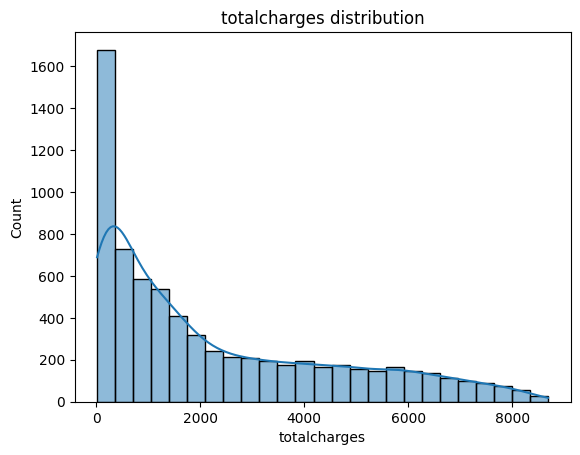

In [247]:
print("Missing totalcharges:", df['totalcharges'].isna().sum())
print(df['totalcharges'].describe())
print("Skew:", df['totalcharges'].skew())

import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['totalcharges'].dropna(), kde=True)
plt.title('totalcharges distribution')
plt.show()

In [248]:
df["totalcharges"].fillna(0,inplace=True)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_12536\2235037750.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["totalcharges"].fillna(0,inplace=True)


In [249]:
ob_cols = df.select_dtypes(include=["object"])
ob_cols

,gender,partner,dependents,multiplelines,contract,paperlessbilling,paymentmethod,churn
0,Female,Yes,No,No phone service,Month-to-month,Yes,Electronic check,No
1,Male,No,No,No,One year,No,Mailed check,No
2,Male,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No phone service,One year,No,Bank transfer (automatic),No
4,Female,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,Female,Yes,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,Female,Yes,Yes,No phone service,Month-to-month,Yes,Electronic check,No
7041,Male,Yes,No,Yes,Month-to-month,Yes,Mailed check,Yes


In [250]:
df.isna().sum()

gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
multiplelines       0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
service             0
churn               0
dtype: int64

In [251]:
for col in ob_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: gender
[' Female' ' Male  ']

Column: partner
[' Yes    ' ' No     ']

Column: dependents
[' No        ' ' Yes       ']

Column: multiplelines
[' No phone service' ' No              ' ' Yes             ']

Column: contract
[' Month-to-month' ' One year      ' ' Two year      ']

Column: paperlessbilling
[' Yes             ' ' No              ']

Column: paymentmethod
[' Electronic check         ' ' Mailed check             '
 ' Bank transfer (automatic)' ' Credit card (automatic)  ']

Column: churn
[' No' ' Yes']


In [252]:
for col in df:
    print(col)
    print(df[col].unique(),"\n")

gender
[' Female' ' Male  '] 

seniorcitizen
[0 1] 

partner
[' Yes    ' ' No     '] 

dependents
[' No        ' ' Yes       '] 

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39] 

multiplelines
[' No phone service' ' No              ' ' Yes             '] 

contract
[' Month-to-month' ' One year      ' ' Two year      '] 

paperlessbilling
[' Yes             ' ' No              '] 

paymentmethod
[' Electronic check         ' ' Mailed check             '
 ' Bank transfer (automatic)' ' Credit card (automatic)  '] 

monthlycharges
[29.85 56.95 53.85 ... 63.1  44.2  78.7 ] 

totalcharges
[  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ] 

service
[1] 

churn
[' No' ' Yes'] 



In [253]:
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

In [254]:
for col in df:
    print(col)
    print(df[col].unique(),"\n")

gender
['Female' 'Male'] 

seniorcitizen
[0 1] 

partner
['Yes' 'No'] 

dependents
['No' 'Yes'] 

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39] 

multiplelines
['No phone service' 'No' 'Yes'] 

contract
['Month-to-month' 'One year' 'Two year'] 

paperlessbilling
['Yes' 'No'] 

paymentmethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] 

monthlycharges
[29.85 56.95 53.85 ... 63.1  44.2  78.7 ] 

totalcharges
[  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ] 

service
[1] 

churn
['No' 'Yes'] 



In [255]:
for col in ob_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: gender
['Female' 'Male']

Column: partner
['Yes' 'No']

Column: dependents
['No' 'Yes']

Column: multiplelines
['No phone service' 'No' 'Yes']

Column: contract
['Month-to-month' 'One year' 'Two year']

Column: paperlessbilling
['Yes' 'No']

Column: paymentmethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Column: churn
['No' 'Yes']


In [256]:
len(df.columns)

13

In [257]:
df['churn'] = df['churn'].map({'No':0, 'Yes':1})

In [258]:
cat_cols = ['gender','partner','dependents','multiplelines','contract','paperlessbilling','paymentmethod']

In [259]:
df_final = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)
df_final.head()

,gender_Male,partner_Yes,dependents_Yes,multiplelines_No phone service,multiplelines_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,1,0,1,0,0,0,1,0,1,0
1,1,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,0,0,0,1,0,0,1
3,1,0,0,1,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,1,0


In [260]:
num_cols = ['seniorcitizen','tenure','monthlycharges','totalcharges','service']
df_final = pd.concat([df[num_cols], df_final, df['churn']], axis=1)
df_final.head()

,seniorcitizen,tenure,monthlycharges,totalcharges,service,gender_Male,partner_Yes,dependents_Yes,multiplelines_No phone service,multiplelines_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,churn
0,0,1,29.85,29.85,1,0,1,0,1,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,1,0,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,1,0,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,1,0,0,1,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,0,0,0,0,1,0,1,0,1


In [261]:
len(df_final.columns)

17

In [262]:
corr = df_final.corr()
corr

,seniorcitizen,tenure,monthlycharges,totalcharges,service,gender_Male,partner_Yes,dependents_Yes,multiplelines_No phone service,multiplelines_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,churn
seniorcitizen,1.000000,0.016567,0.220173,0.103006,NaN,-0.001874,0.016479,-0.211185,-0.008576,0.142948,-0.046262,-0.117000,0.156530,-0.024135,0.171718,-0.153477,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,NaN,0.005106,0.379697,0.159712,-0.008448,0.331941,0.202570,0.558533,0.006152,0.233006,-0.208363,-0.233852,-0.352229
monthlycharges,0.220173,0.247900,1.000000,0.651174,NaN,-0.014569,0.096848,-0.113890,-0.247398,0.490434,0.004904,-0.074681,0.352150,0.030550,0.271625,-0.377437,0.193356
totalcharges,0.103006,0.826178,0.651174,1.000000,NaN,-0.000080,0.317504,0.062078,-0.113214,0.468504,0.170814,0.354481,0.158574,0.182915,-0.059246,-0.295758,-0.198324
service,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender_Male,-0.001874,0.005106,-0.014569,-0.000080,NaN,1.000000,-0.001808,0.010517,0.006488,-0.008414,0.008026,-0.003695,-0.011754,0.001215,0.000752,0.013744,-0.008612
partner_Yes,0.016479,0.379697,0.096848,0.317504,NaN,-0.001808,1.000000,0.452676,-0.017706,0.142057,0.082783,0.248091,-0.014877,0.082029,-0.083852,-0.095125,-0.150448
dependents_Yes,-0.211185,0.159712,-0.113890,0.062078,NaN,0.010517,0.452676,1.000000,0.001762,-0.024526,0.068368,0.204613,-0.111377,0.060267,-0.150642,0.059071,-0.164221
multiplelines_No phone service,-0.008576,-0.008448,-0.247398,-0.113214,NaN,0.006488,-0.017706,0.001762,1.000000,-0.279690,0.002791,-0.003519,-0.016505,0.007721,-0.003062,0.003319,-0.011942
multiplelines_Yes,0.142948,0.331941,0.490434,0.468504,NaN,-0.008414,0.142057,-0.024526,-0.279690,1.000000,-0.003794,0.106253,0.163530,0.060048,0.083618,-0.227206,0.040102


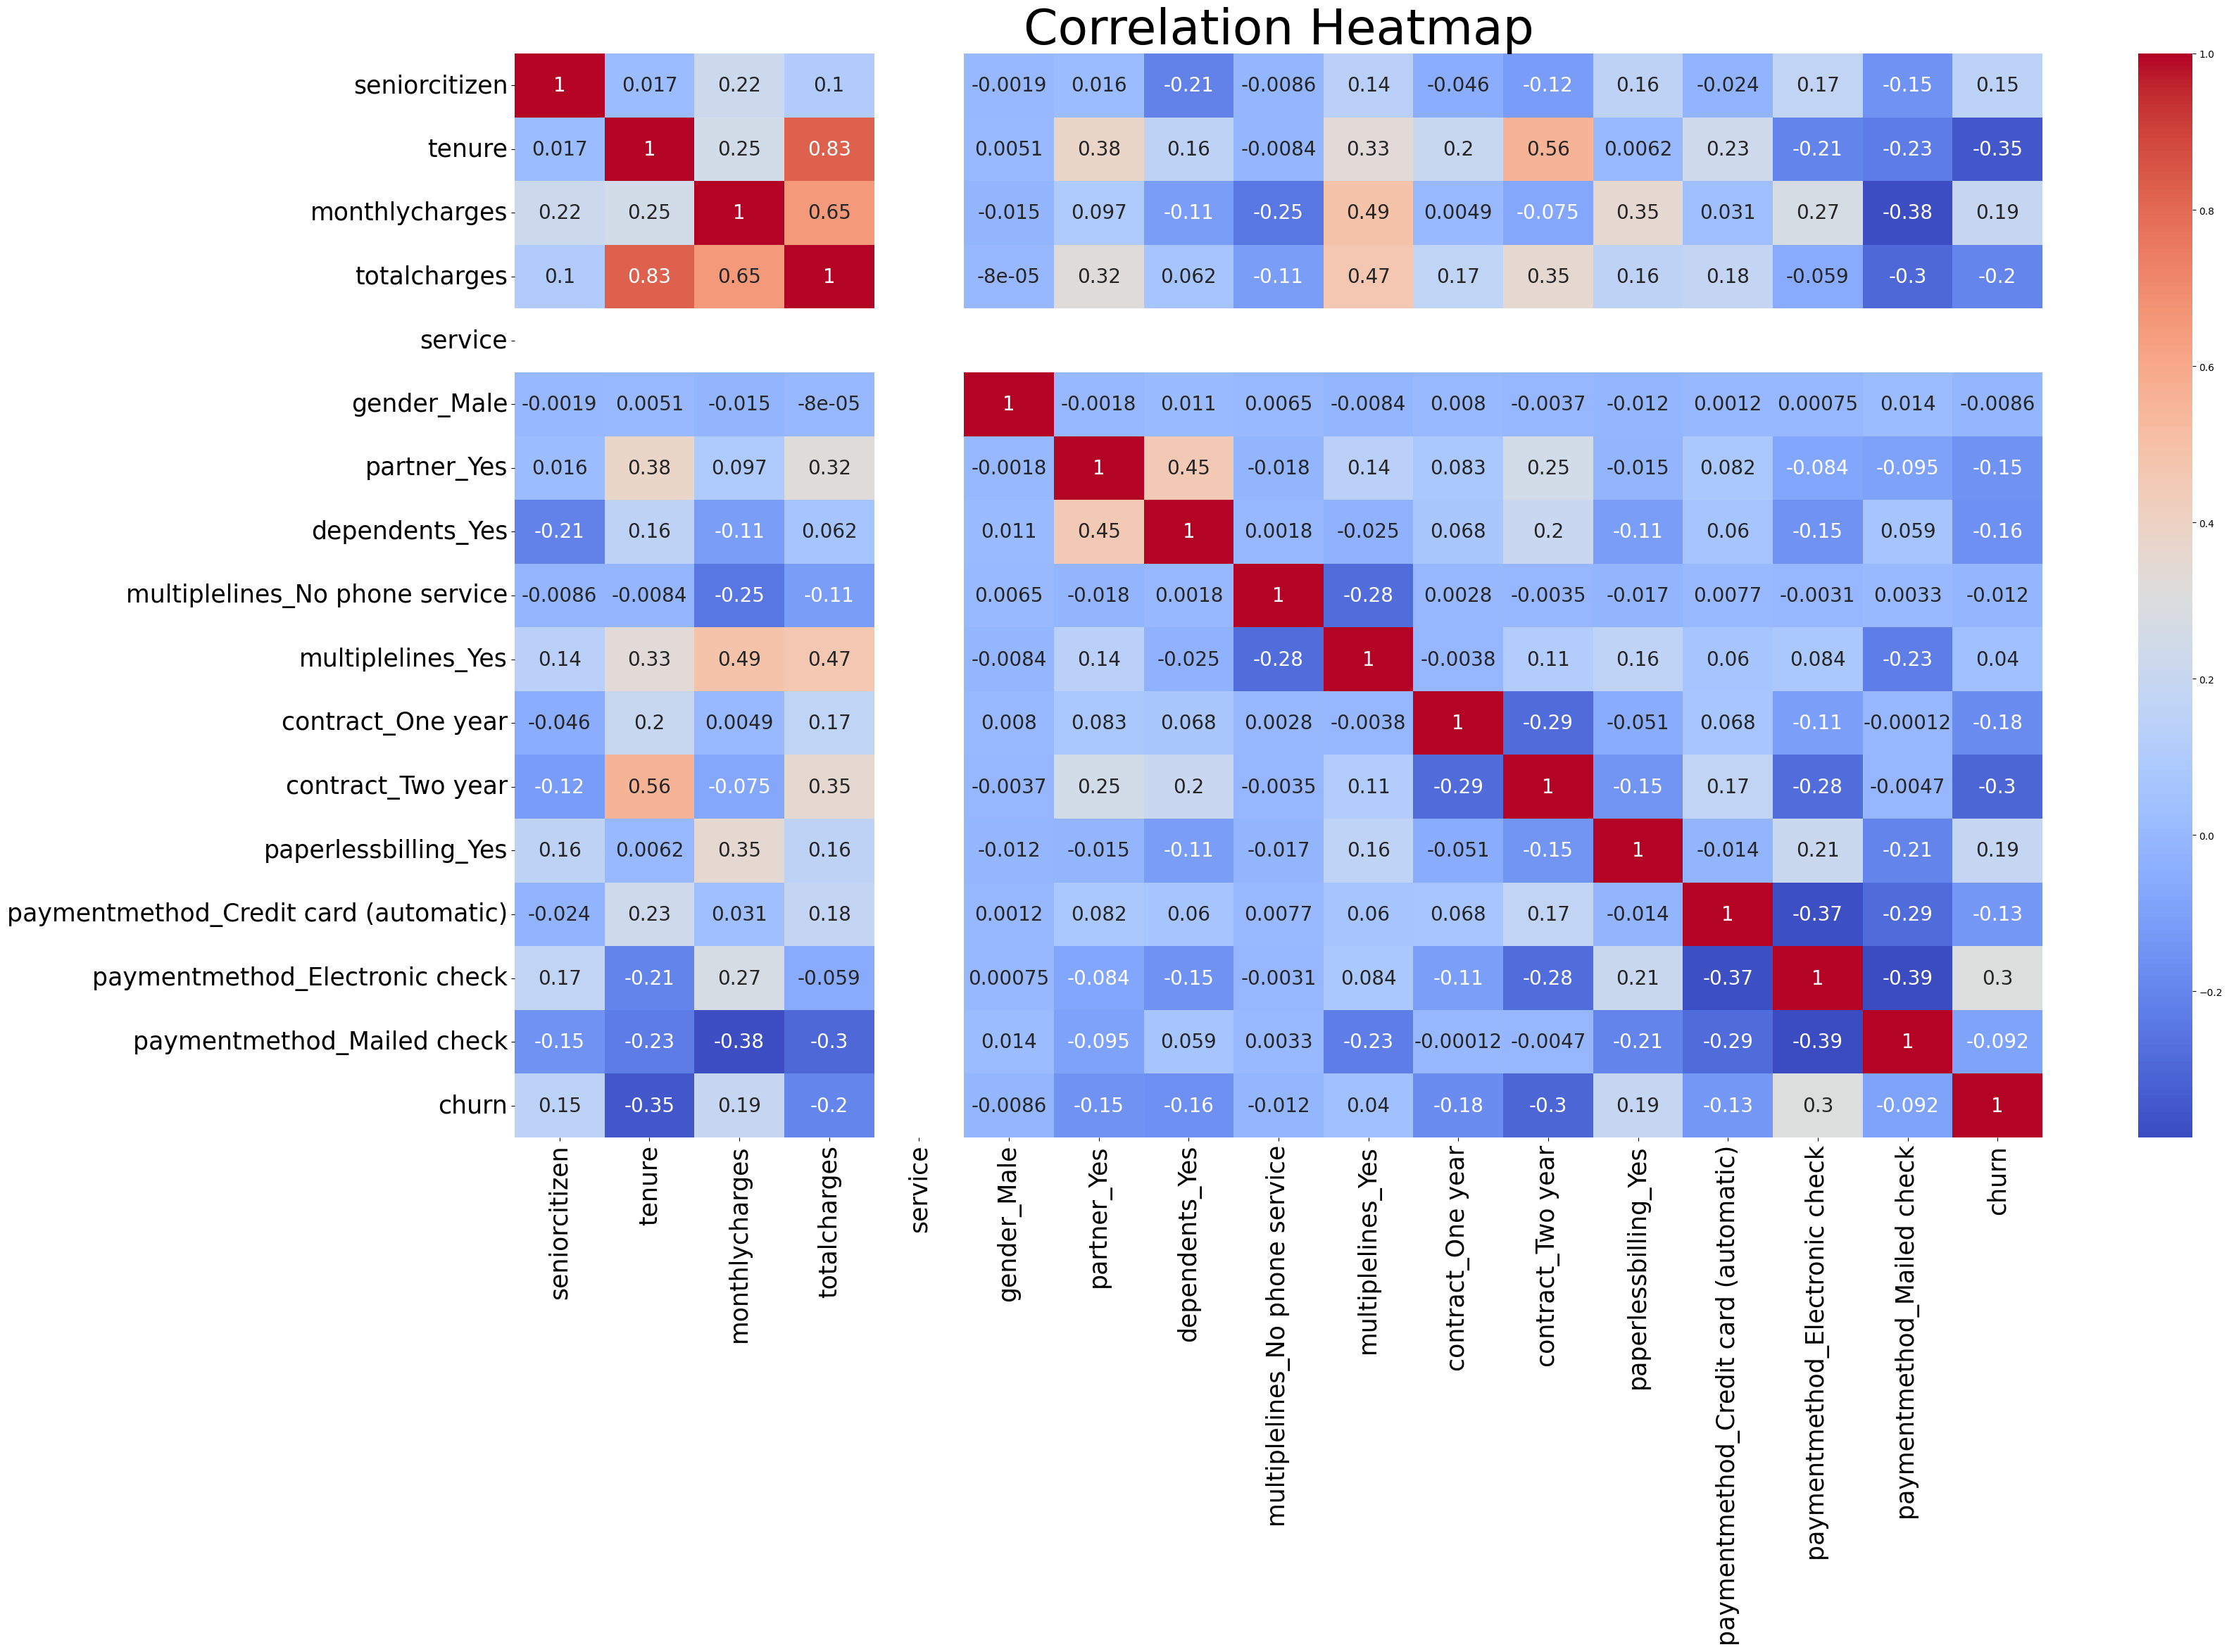

In [263]:
plt.figure(figsize=(35, 20))  
sns.heatmap(corr, annot=True,annot_kws={"size": 20}, cmap='coolwarm')  
plt.title("Correlation Heatmap", fontsize=50)
plt.xticks(fontsize=25, rotation=90)  
plt.yticks(fontsize=25, rotation=0) 
plt.show()

In [264]:
target_corr = corr["churn"].sort_values(ascending=False)
target_corr

churn                                    1.000000
paymentmethod_Electronic check           0.301919
monthlycharges                           0.193356
paperlessbilling_Yes                     0.191825
seniorcitizen                            0.150889
multiplelines_Yes                        0.040102
gender_Male                             -0.008612
multiplelines_No phone service          -0.011942
paymentmethod_Mailed check              -0.091683
paymentmethod_Credit card (automatic)   -0.134302
partner_Yes                             -0.150448
dependents_Yes                          -0.164221
contract_One year                       -0.177820
totalcharges                            -0.198324
contract_Two year                       -0.302253
tenure                                  -0.352229
service                                       NaN
Name: churn, dtype: float64

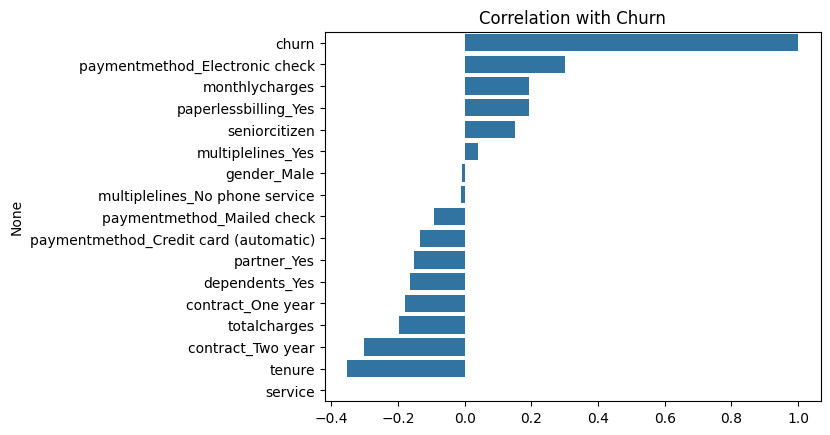

In [265]:
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Correlation with Churn")
plt.show()

In [266]:
df_final.drop("service",axis=1 ,inplace=True)
df_final.head()

,seniorcitizen,tenure,monthlycharges,totalcharges,gender_Male,partner_Yes,dependents_Yes,multiplelines_No phone service,multiplelines_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,churn
0,0,1,29.85,29.85,0,1,0,1,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,1,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,0,0,0,0,1,0,1,0,1


In [267]:
numeric_cols = ['tenure', 'monthlycharges', 'totalcharges']

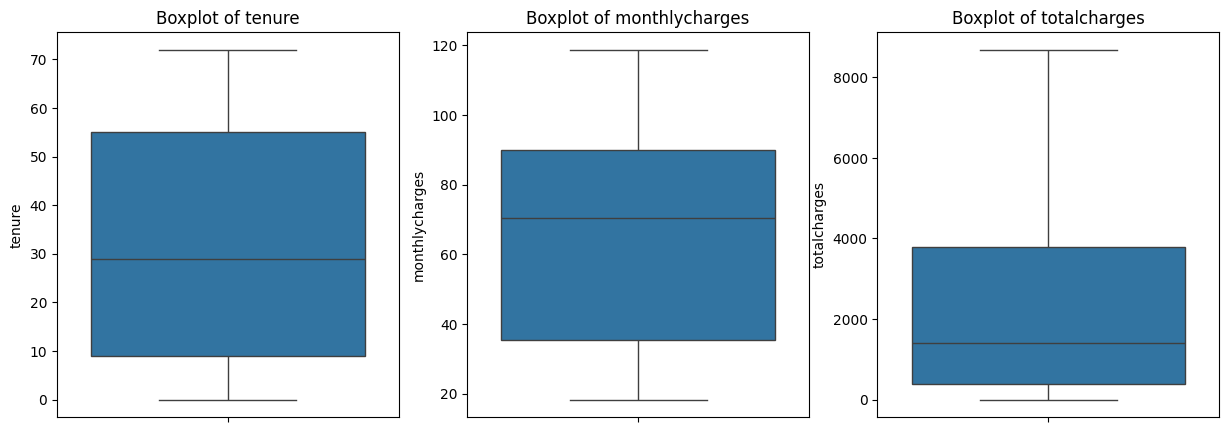

In [268]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_final[col])
    plt.title(f'Boxplot of {col}')

#plt.tight_layout()
plt.show()

In [269]:
for col in numeric_cols:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df_final[(df_final[col] < lower) | (df_final[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")


tenure: 0 outliers
monthlycharges: 0 outliers
totalcharges: 0 outliers


In [270]:
df_final.head(10)

,seniorcitizen,tenure,monthlycharges,totalcharges,gender_Male,partner_Yes,dependents_Yes,multiplelines_No phone service,multiplelines_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,churn
0,0,1,29.85,29.85,0,1,0,1,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,1,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,0,0,0,0,1,0,1,0,1
5,0,8,99.65,820.50,0,0,0,0,1,0,0,1,0,1,0,1
6,0,22,89.10,1949.40,1,0,1,0,1,0,0,1,1,0,0,0
7,0,10,29.75,301.90,0,0,0,1,0,0,0,0,0,0,1,0
8,0,28,104.80,3046.05,0,1,0,0,1,0,0,1,0,1,0,1
9,0,62,56.15,3487.95,1,0,1,0,0,1,0,0,0,0,0,0


In [271]:
df_final.dtypes

seniorcitizen                              int64
tenure                                     int64
monthlycharges                           float64
totalcharges                             float64
gender_Male                                int64
partner_Yes                                int64
dependents_Yes                             int64
multiplelines_No phone service             int64
multiplelines_Yes                          int64
contract_One year                          int64
contract_Two year                          int64
paperlessbilling_Yes                       int64
paymentmethod_Credit card (automatic)      int64
paymentmethod_Electronic check             int64
paymentmethod_Mailed check                 int64
churn                                      int64
dtype: object

In [272]:
X = df_final.drop("churn",axis=1)
y = df_final["churn"]

X_train , X_test , y_train , y_test = train_test_split(X , y, test_size=0.2 , stratify=y)

# scaling

In [273]:
numeric_cols = [ 'tenure', 'monthlycharges', 'totalcharges']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# fixing class imbalance

In [274]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_res , y_train_res = smote.fit_resample(X_train,y_train)

In [275]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE :", y_train_res.value_counts())

Before SMOTE: churn
0    4139
1    1495
Name: count, dtype: int64
After SMOTE : churn
0    4139
1    4139
Name: count, dtype: int64


In [276]:
df_final.duplicated().sum()

np.int64(22)

In [277]:
df_res = pd.concat([X_train_res, y_train_res.reset_index(drop=True)], axis=1)
df_res = df_res.drop_duplicates()
X_train_res = df_res.drop('churn', axis=1)
y_train_res = df_res['churn']

In [278]:
df_res.duplicated().sum()

np.int64(0)

In [279]:
y_train_res_value_counts = y_train_res.value_counts()

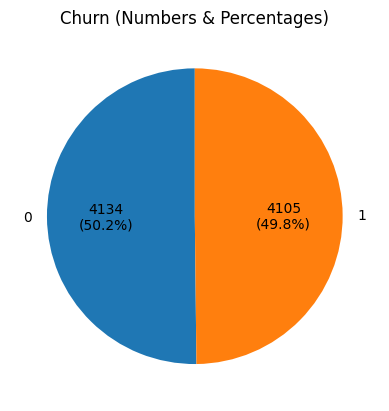

In [280]:
plt.pie(
    y_train_res_value_counts,
    labels=y_train_res_value_counts.index,
    startangle=90,
    autopct=lambda p: f'{int(p/100 * sum(y_train_res_value_counts))}\n({p:.1f}%)'
)
plt.title('Churn (Numbers & Percentages)')
plt.show()

In [281]:
X = pd.get_dummies(df, drop_first=True)
import pickle
pickle.dump(X_train.columns.tolist(), open("model_columns.pkl", "wb"))


# Training Model 

In [282]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay,classification_report, roc_auc_score, roc_curve

## Applying naive bayes

In [283]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_res, y_train_res)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7366926898509581
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



TN: 749
FP: 286
FN: 85
TP: 289


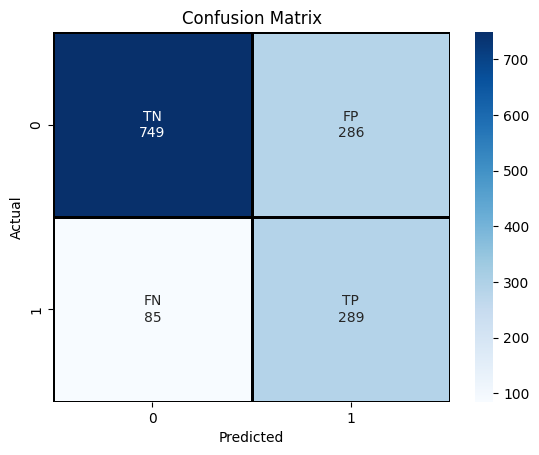

In [284]:
cm = confusion_matrix(y_test, y_pred_nb)
tn, fp, fn, tp = cm.ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

labels =[["TN\n" + str(tn), "FP\n" + str(fp)],
        ["FN\n" + str(fn), "TP\n" + str(tp)]]

plt.style.use("default")
sns.heatmap(
    cm,annot=labels,fmt="",cmap="Blues",linewidths=1,linecolor="black"
)


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [285]:
y_pred_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]
y_pred_prob = nb.predict_proba(X_test_scaled)[:,1]
print("AUC:", roc_auc_score(y_test, y_pred_prob))

AUC: 0.8115322018135318


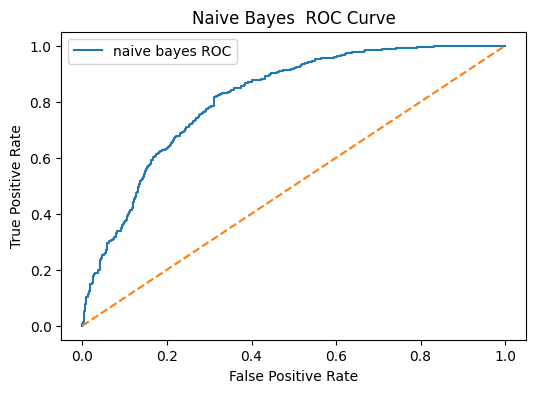

In [286]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_nb)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="naive bayes ROC")
plt.plot([0, 1], [0, 1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes  ROC Curve")
plt.legend()
plt.show()

## Applying Decision tree 

In [287]:
from sklearn.tree import DecisionTreeClassifier

In [288]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7260468417317246
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.48      0.49      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



TN: 839
FP: 196
FN: 190
TP: 184


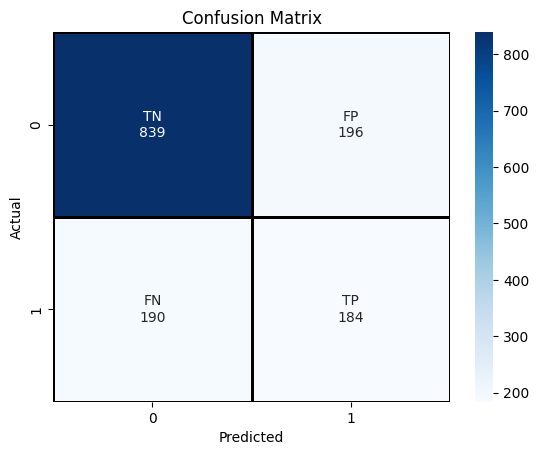

In [289]:
cm = confusion_matrix(y_test, y_pred_dt)
tn, fp, fn, tp = cm.ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

labels =[["TN\n" + str(tn), "FP\n" + str(fp)],
        ["FN\n" + str(fn), "TP\n" + str(tp)]]

plt.style.use("default")
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    linewidths=1,
    linecolor="black"
)


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [290]:
y_pred_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]
y_pred_prob = dt.predict_proba(X_test_scaled)[:,1]
print("AUC:", roc_auc_score(y_test, y_pred_prob))

AUC: 0.5


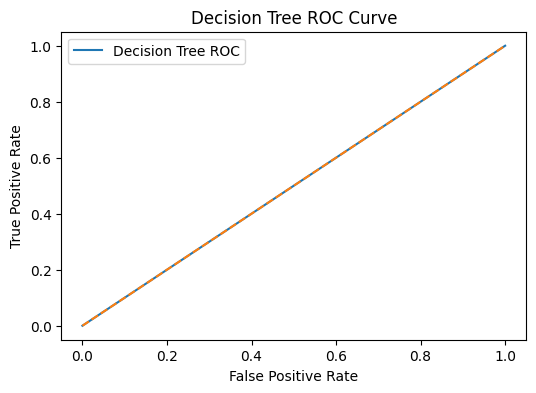

In [291]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_dt)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="Decision Tree ROC")
plt.plot([0, 1], [0, 1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

# Applying Xgboost

XGBoost Accuracy: 0.7374024130589071
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1035
           1       0.83      0.01      0.03       374

    accuracy                           0.74      1409
   macro avg       0.79      0.51      0.44      1409
weighted avg       0.76      0.74      0.63      1409

XGBoost AUC: 0.8157392337699243


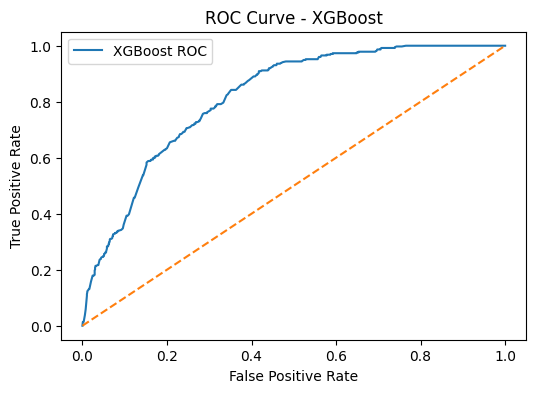

In [292]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score
import matplotlib.pyplot as plt

# Model
xgb_model = xgb.XGBClassifier(
    n_estimators=550,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))


auc_xgb = roc_auc_score(y_test, y_pred_prob_xgb)
print("XGBoost AUC:", auc_xgb)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_xgb)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="XGBoost ROC")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()


TN: 1034
FP: 1
FN: 369
TP: 5


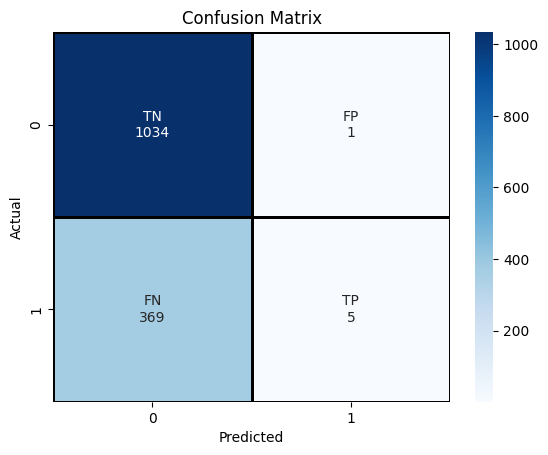

In [293]:
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

labels =[["TN\n" + str(tn), "FP\n" + str(fp)],
        ["FN\n" + str(fn), "TP\n" + str(tp)]]

plt.style.use("default")
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    linewidths=1,
    linecolor="black"
)


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Xgboost - second try 
## goal is :

1. Decreas  FN
2. increase Recall

In [294]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

In [295]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix, roc_auc_score, roc_curve

In [296]:
xgb = XGBClassifier(
    scale_pos_weight=1,  # SMOTE balanced data
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 5],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_res, y_train_res)

best_xgb = grid.best_estimator_
print("Best params:", grid.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


In [297]:
y_proba = best_xgb.predict_proba(X_test_scaled)[:,1]

In [298]:
thresholds = [0.5, 0.45, 0.4, 0.35, 0.3]
f1_scores = []
recall_scores = []
precision_scores = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))
    recall_scores.append(recall_score(y_test, preds))
    precision_scores.append(precision_score(y_test, preds))
    print(f"Threshold {t} -> F1: {f1_score(y_test, preds):.3f}, Recall: {recall_score(y_test, preds):.3f}, Precision: {precision_score(y_test, preds):.3f}")


Threshold 0.5 -> F1: 0.559, Recall: 0.567, Precision: 0.552
Threshold 0.45 -> F1: 0.601, Recall: 0.786, Precision: 0.486
Threshold 0.4 -> F1: 0.596, Recall: 0.842, Precision: 0.461
Threshold 0.35 -> F1: 0.600, Recall: 0.877, Precision: 0.456
Threshold 0.3 -> F1: 0.548, Recall: 0.939, Precision: 0.387


In [299]:
best_threshold = 0.35
y_pred_custom = (y_proba >= best_threshold).astype(int)

In [300]:
print("\n--- Evaluation at Threshold =", best_threshold, "---")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1 Score:", f1_score(y_test, y_pred_custom))


--- Evaluation at Threshold = 0.35 ---
Accuracy: 0.6898509581263307
Recall: 0.8770053475935828
F1 Score: 0.6001829826166514


TN: 644
FP: 391
FN: 46
TP: 328


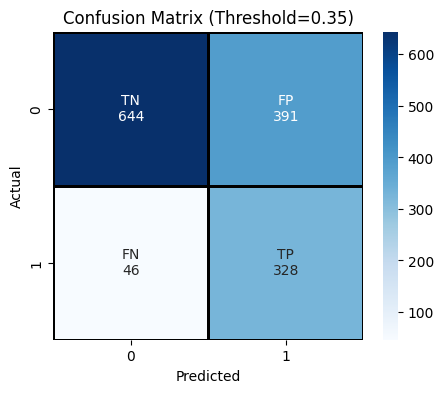

In [301]:
cm = confusion_matrix(y_test, y_pred_custom)
tn, fp, fn, tp = cm.ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

labels =[["TN\n" + str(tn), "FP\n" + str(fp)],
        ["FN\n" + str(fn), "TP\n" + str(tp)]]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", linewidths=1, linecolor="black")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Threshold={best_threshold})")
plt.show()

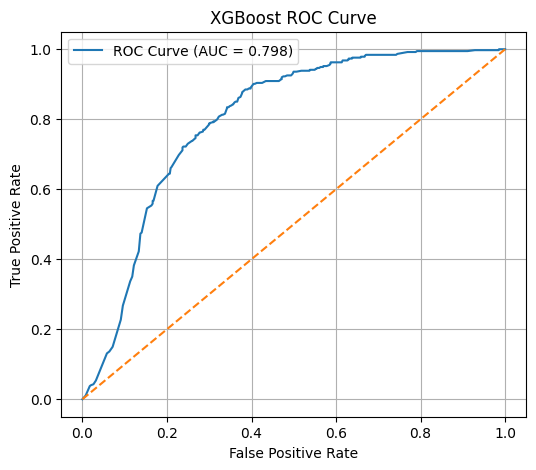

In [302]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Saving the model 

In [303]:
import joblib

In [304]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [305]:
joblib.dump(best_xgb, "xgb_churn_model.pkl")

['xgb_churn_model.pkl']

In [306]:
import os
os.getcwd()

'c:\\Python\\dr wael'

In [307]:
df_final.columns

Index(['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges',
       'gender_Male', 'partner_Yes', 'dependents_Yes',
       'multiplelines_No phone service', 'multiplelines_Yes',
       'contract_One year', 'contract_Two year', 'paperlessbilling_Yes',
       'paymentmethod_Credit card (automatic)',
       'paymentmethod_Electronic check', 'paymentmethod_Mailed check',
       'churn'],
      dtype='object')

In [308]:
columns = joblib.load("model_columns.pkl")
print("Model Feature Names:")
print(columns)

Model Feature Names:
['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges', 'gender_Male', 'partner_Yes', 'dependents_Yes', 'multiplelines_No phone service', 'multiplelines_Yes', 'contract_One year', 'contract_Two year', 'paperlessbilling_Yes', 'paymentmethod_Credit card (automatic)', 'paymentmethod_Electronic check', 'paymentmethod_Mailed check']
